# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [4]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [5]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Simulation study

In [155]:
history_strength_list = np.arange(0, -5, -0.5)
fano = []
fano_pop = []
fano_se = []
fano_se_pop = []

for history_strength in history_strength_list:
    nneuron = 10
    nt = 500
    ntrial = 1000

    baseline_mat = np.log(0.05)*np.ones((nt, nneuron))

    coupling_decay = 5
    coupling_length = 30
    coupling_strength = 0.0
    time_line_coupling = np.arange(coupling_length)
    ground_truth_coupling_filter = coupling_strength*np.exp(-time_line_coupling/coupling_decay)

    history_decay = 5
    history_length = 30
#     history_strength = 0
    time_line_history = np.arange(history_length)
    ground_truth_history_filter = history_strength*np.exp(-time_line_history/history_decay)

    max_histories = max((history_length, coupling_length))
    coupling_mat = np.zeros((max_histories, nneuron, nneuron))
    for ineuron in range(nneuron):
        for jneuron in range(nneuron):
            if ineuron==jneuron:
                coupling_mat[-history_length:, ineuron, jneuron] = np.flip(ground_truth_history_filter)
            else:
                coupling_mat[-coupling_length:, ineuron, jneuron] = np.flip(ground_truth_coupling_filter)

    spike_trains = np.zeros((nt, nneuron, ntrial))
    for itrial in tqdm(range(ntrial)):
        spikes, log_firing_rate = GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
        spike_trains[:,:,itrial] = spikes

    temp = [np.var(spike_trains[:,:,i])/np.mean(spike_trains[:,:,i]) for i in range(ntrial)]
    fano.append( np.mean(temp) )
    fano_se.append( 2*np.std(temp)/np.sqrt(ntrial) )
    
    spike_trains_pop = spike_trains.sum(axis=1)
    temp = [np.var(spike_trains_pop[:,i])/np.mean(spike_trains_pop[:,i]) for i in range(ntrial)]
    fano_pop.append( np.mean(temp) )
    fano_se_pop.append( 2*np.std(temp)/np.sqrt(ntrial) )

100%|████████████████████████████████| 1000/1000 [00:13<00:00, 73.46it/s]


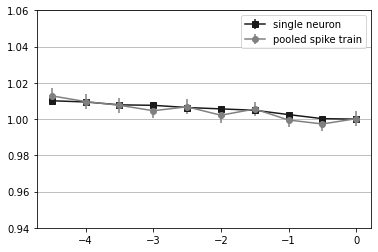

In [156]:
plt.errorbar(history_strength_list, fano, yerr=fano_se, label="single neuron", marker='s', color='k')
plt.errorbar(history_strength_list, fano_pop, yerr=fano_se_pop, label="pooled spike train", marker='o', color='grey')
plt.legend()
plt.ylim([0.94, 1.06])
plt.grid(axis = 'y')
# plt.axhline(1, color='k', lw=1)

In [153]:
coupling_strength_list = np.arange(0, 0.25, 0.05)
fano = []
fano_pop = []
fano_se = []
fano_se_pop = []

for coupling_strength in coupling_strength_list:
    nneuron = 10
    nt = 500
    ntrial = 1000

    baseline_mat = np.log(0.05)*np.ones((nt, nneuron))

    coupling_decay = 5
    coupling_length = 30
#     coupling_strength = 0.0
    time_line_coupling = np.arange(coupling_length)
    ground_truth_coupling_filter = coupling_strength*np.exp(-time_line_coupling/coupling_decay)

    history_decay = 2
    history_length = 30
    history_strength = -5
    time_line_history = np.arange(history_length)
    ground_truth_history_filter = history_strength*np.exp(-time_line_history/history_decay)

    max_histories = max((history_length, coupling_length))
    coupling_mat = np.zeros((max_histories, nneuron, nneuron))
    for ineuron in range(nneuron):
        for jneuron in range(nneuron):
            if ineuron==jneuron:
                coupling_mat[-history_length:, ineuron, jneuron] = np.flip(ground_truth_history_filter)
            else:
                coupling_mat[-coupling_length:, ineuron, jneuron] = np.flip(ground_truth_coupling_filter)

    spike_trains = np.zeros((nt, nneuron, ntrial))
    for itrial in tqdm(range(ntrial)):
        spikes, log_firing_rate = GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
        spike_trains[:,:,itrial] = spikes

    temp = [np.var(spike_trains[:,:,i])/np.mean(spike_trains[:,:,i]) for i in range(ntrial)]
    fano.append( np.mean(temp) )
    fano_se.append( np.std(temp)/np.sqrt(ntrial) )
    
    spike_trains_pop = spike_trains.sum(axis=1)
    temp = [np.var(spike_trains_pop[:,i])/np.mean(spike_trains_pop[:,i]) for i in range(ntrial)]
    fano_pop.append( np.mean(temp) )
    fano_se_pop.append( np.std(temp)/np.sqrt(ntrial) )

100%|████████████████████████████████| 1000/1000 [00:13<00:00, 73.59it/s]


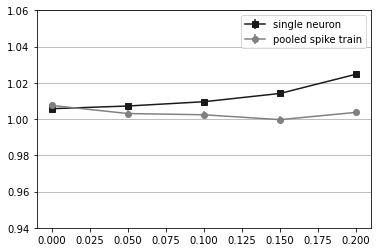

In [154]:
plt.errorbar(coupling_strength_list, fano, yerr=fano_se, label="single neuron", marker='s', color='k')
plt.errorbar(coupling_strength_list, fano_pop, yerr=fano_se_pop, label="pooled spike train", marker='o', color='grey')
plt.legend()
plt.ylim([0.94, 1.06])
plt.grid(axis = 'y')
# plt.axhline(1, color='k', lw=1)

In [158]:
coupling_strength_list = np.arange(0, -0.25, -0.05)
fano = []
fano_pop = []
fano_se = []
fano_se_pop = []

for coupling_strength in coupling_strength_list:
    nneuron = 10
    nt = 500
    ntrial = 1000

    baseline_mat = np.log(0.05)*np.ones((nt, nneuron))

    coupling_decay = 5
    coupling_length = 30
#     coupling_strength = 0.0
    time_line_coupling = np.arange(coupling_length)
    ground_truth_coupling_filter = coupling_strength*np.exp(-time_line_coupling/coupling_decay)

    history_decay = 2
    history_length = 30
    history_strength = -5
    time_line_history = np.arange(history_length)
    ground_truth_history_filter = history_strength*np.exp(-time_line_history/history_decay)

    max_histories = max((history_length, coupling_length))
    coupling_mat = np.zeros((max_histories, nneuron, nneuron))
    for ineuron in range(nneuron):
        for jneuron in range(nneuron):
            if ineuron==jneuron:
                coupling_mat[-history_length:, ineuron, jneuron] = np.flip(ground_truth_history_filter)
            else:
                coupling_mat[-coupling_length:, ineuron, jneuron] = np.flip(ground_truth_coupling_filter)

    spike_trains = np.zeros((nt, nneuron, ntrial))
    for itrial in tqdm(range(ntrial)):
        spikes, log_firing_rate = GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
        spike_trains[:,:,itrial] = spikes

    temp = [np.var(spike_trains[:,:,i])/np.mean(spike_trains[:,:,i]) for i in range(ntrial)]
    fano.append( np.mean(temp) )
    fano_se.append( np.std(temp)/np.sqrt(ntrial) )
    
    spike_trains_pop = spike_trains.sum(axis=1)
    temp = [np.var(spike_trains_pop[:,i])/np.mean(spike_trains_pop[:,i]) for i in range(ntrial)]
    fano_pop.append( np.mean(temp) )
    fano_se_pop.append( np.std(temp)/np.sqrt(ntrial) )

100%|████████████████████████████████| 1000/1000 [00:14<00:00, 68.00it/s]


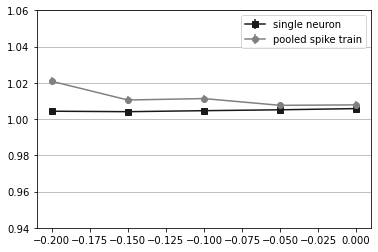

In [159]:
plt.errorbar(coupling_strength_list, fano, yerr=fano_se, label="single neuron", marker='s', color='k')
plt.errorbar(coupling_strength_list, fano_pop, yerr=fano_se_pop, label="pooled spike train", marker='o', color='grey')
plt.legend()
plt.ylim([0.94, 1.06])
plt.grid(axis = 'y')
# plt.axhline(1, color='k', lw=1)

# Real data

In [255]:
### Get the id of neurons that are classified as cross-pop
num_neurons = 5

stimulus_condition_id = [275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270]
probe_list = V1.selected_probes
for target_probe in probe_list:
    cross_pop_list = []
    cross_pop_conditions = {}
    for neuron in membership[0].index:
        if membership[1].loc[neuron]['probe'] == target_probe:
            for i, member in enumerate(membership):
                if member.loc[neuron]['group_id'] == 0:
                    if condition_ids[i] in stimulus_condition_id:
                        if neuron not in cross_pop_conditions:
                            cross_pop_list.append(neuron)
                            cross_pop_conditions[neuron] = [condition_ids[i]]
                        else:
                            cross_pop_conditions[neuron].append(condition_ids[i])
    cross_pop_conditions = dict(sorted(cross_pop_conditions.items(), key=lambda item: len(item[1]), reverse=True))
    major_cross_pop_list = list(cross_pop_conditions.keys())[:num_neurons]
    
    dataset = V1
    use_all = False
    spike_train = dataset.spike_train
    nunit = len(cross_pop_list)
    condition_list = dataset.presentation_table['stimulus_condition_id']
    nt = len(spike_train.iloc[0,0])
    ntrial = spike_train.shape[1]
    spikes = np.zeros((nt, nunit, ntrial)) 

    for iunit, unit in enumerate(cross_pop_list):
        for itrial in range(ntrial):
            spikes[:, iunit, itrial] = spike_train.loc[unit, spike_train.columns[itrial]]
    
    spike_trains = spikes
    temp = [np.var(spike_trains[:,:,i])/np.mean(spike_trains[:,:,i]) for i in range(ntrial)]
    fano = np.mean(temp)
    fano_se = np.std(temp)/np.sqrt(ntrial)

    spike_trains_pop = spike_trains.sum(axis=1)
    temp = [np.var(spike_trains_pop[:,i])/np.mean(spike_trains_pop[:,i]) for i in range(ntrial)]
    fano_pop = np.mean(temp)
    fano_se_pop = np.std(temp)/np.sqrt(ntrial)
    
    print(f"{target_probe}")
    print(f"FF single: {fano:.3f} ({fano_se:.3f}) ")
    print(f"FF population: {fano_pop:.3f} ({fano_se_pop:.3f}) ")
#     temp = [np.var(spike_trains[:,i,:])/np.mean(spike_trains[:,i,:]) for i in range(nunit)]
    

probeA
FF single: 0.987 (0.000) 
FF population: 1.198 (0.010) 
probeB
FF single: 0.993 (0.000) 
FF population: 1.090 (0.007) 
probeC
FF single: 0.990 (0.000) 
FF population: 1.380 (0.017) 
probeD
FF single: 0.991 (0.000) 
FF population: 1.183 (0.009) 
probeE
FF single: 0.988 (0.000) 
FF population: 1.237 (0.010) 
probeF
FF single: 0.992 (0.000) 
FF population: 1.041 (0.005) 


In [252]:
temp = [np.var(spike_trains[:,i,:])/np.mean(spike_trains[:,i,:]) for i in range(nunit)]
fano = np.mean(temp)

In [253]:
temp

[0.9909523809523808,
 0.9927976190476188,
 0.9976749931186351,
 0.9914843986494348,
 0.9855476190476191,
 0.9943154761904761,
 0.9832499999999993,
 1.001435264297106,
 0.9866904761904762,
 0.9979090588898281,
 0.9966011904761907,
 0.991666666666667,
 0.9964702380952382,
 0.9934702380952383,
 0.9841624096752426,
 0.9956071428571422,
 0.986863095238095]

probeA
FF single: 0.987 (0.000) 
FF population: 1.198 (0.010) 
probeB
FF single: 0.993 (0.000) 
FF population: 1.090 (0.007) 
probeC
FF single: 0.990 (0.000) 
FF population: 1.380 (0.017) 
probeD
FF single: 0.991 (0.000) 
FF population: 1.183 (0.009) 
probeE
FF single: 0.988 (0.000) 
FF population: 1.237 (0.010) 
probeF
FF single: 0.992 (0.000) 
FF population: 1.041 (0.005) 

# Spike trains of condition-related selected neurons

## Real data

In [256]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
# coupling_filter_params = {'peaks_max':26, 'num':3, 'nonlinear':0.9}
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    

6it [03:14, 32.47s/it]


In [262]:
# Population spike train Fano factor
for i, target_probe in enumerate(probe_list):
    spike_trains_pop = np.hstack((stationary_model_list[i].output, running_model_list[i].output))
    temp = [np.var(spike_trains_pop[:,i])/np.mean(spike_trains_pop[:,i]) for i in range(spike_trains_pop.shape[1])]
    fano_pop = np.mean(temp)
    fano_se_pop = np.std(temp)/np.sqrt(ntrial)

    print(f"{target_probe}")
    print(f"FF population: {fano_pop:.3f} ({fano_se_pop:.3f}) ")

probeA
FF population: 1.165 (0.010) 
probeB
FF population: 1.082 (0.007) 
probeC
FF population: 1.329 (0.017) 
probeD
FF population: 1.143 (0.010) 
probeE
FF population: 1.121 (0.011) 
probeF
FF population: 1.024 (0.006) 


## Simulation

In [264]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
# coupling_filter_params = {'peaks_max':26, 'num':3, 'nonlinear':0.9}
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    

6it [03:17, 32.93s/it]


In [ ]:
# Simulate stationary
stationary_results = GLM.simulate_baseline_coupling_refractory(stationary_model_list, 
                                                               nepoch=100, offset=0.0)

 28%|█████████▊                         | 28/100 [03:05<07:56,  6.62s/it]

In [ ]:
# Simulate running
running_results = GLM.simulate_baseline_coupling_refractory(running_model_list, 
                                                            nepoch=100, offset=0.0)

In [288]:
from numpy import random
aaa = np.stack((random.poisson(0.01, size=10000),random.poisson(0.1, size=10000) ))
print(aaa.var()/aaa.mean())

1.0504545454545458


In [ ]:
# Simualted population spike train Fano factor
for i, target_probe in enumerate(probe_list):
    spike_trains_pop = np.hstack((stationary_results[0][:,:,i], running_results[0][:,:,i]))
    temp = [np.var(spike_trains_pop[:,i])/np.mean(spike_trains_pop[:,i]) for i in range(spike_trains_pop.shape[1])]
    fano_pop = np.mean(temp)
    fano_se_pop = np.std(temp)/np.sqrt(spike_trains_pop.shape[1])

    print(f"{target_probe}")
    print(f"FF population: {fano_pop:.3f} ({fano_se_pop:.3f}) ")